## Introduction 

In this script, the straightness per ward is computed. First, the straightness for the entire Bangalore is computed and then a loop is created where the straightness for each ward is obtained. 

## Reading in the Python libraries

In [25]:
from pathlib import Path

import geopandas as gpd
import momepy
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

## Loading the data

In [26]:
BASE_DIR = Path.cwd().parent
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_chennai" / "chennai_graphml.graphml"

# WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
# WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [27]:
## Detailed wards
df_inpath = PROCESSED_DIR / "chennai_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\chennai_fix_mapshaper.shp


In [28]:
df = gpd.read_file(df_inpath)
df.head()

,Name,zone_id,zone_name,geometry
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584..."
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ..."
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ..."
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13...."
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318..."


In [29]:
print(f'There are {df.shape[0]} wards in the dataset.')

There are 200 wards in the dataset.


Reading in the entire Chennai network data that we had downloaded earlier as again we will "truncate" the network to the different street networks at the ward level:

In [30]:
G = ox.io.load_graphml(path_graphml)

In [31]:
G.graph["crs"]

'epsg:4326'

In [32]:
df.crs.to_epsg()

4326

## Computing street straightness at the ward level

In [33]:
results = pd.DataFrame(columns=['Name', 'zone_id', 'zone_name', 'straightness'])
results

,Name,zone_id,zone_name,straightness


In [34]:
## for ward in tqdm(range(0,5), desc="Processing wards"):
for ward in tqdm(range(0,len(df)), desc = "Processing wards"):

    ## print(f'Processing the {ward} ward.')

    Name = df['Name'].iloc[ward]
    zone_id = df['zone_id'].iloc[ward]
    zone_name = df['zone_name'].iloc[ward]
    
    ## print(name_ward)

    df_ward = df.iloc[[ward]]

    ## ward_geometry = df.iloc[ward,:].geometry
    ward_geometry = df_ward.geometry.iloc[0]

    ## https://docs.momepy.org/en/stable/user_guide/simple/shape.html#Street-network-shapes
    G_clipped = ox.truncate.truncate_graph_polygon(G, ward_geometry)

    streets_graph = ox.projection.project_graph(G_clipped)

    edges = ox.graph_to_gdfs(
    ox.convert.to_undirected(streets_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
    )

    primal = momepy.gdf_to_nx(edges, approach="primal")

    primal = momepy.straightness_centrality(primal)

    nodes = momepy.nx_to_gdf(primal, lines=False)


    straightness_mean = nodes['straightness'].mean()

    ## print(straightness_mean)

    results.loc[ward] = [
        Name,
        zone_id,
        zone_name,
        straightness_mean
    ]
    

Processing wards: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [19:56<00:00,  5.98s/it]


In [35]:
results

,Name,zone_id,zone_name,straightness
0,168,13,Adyar,0.674565
1,169,13,Adyar,0.581726
2,170,13,Adyar,0.687670
3,171,13,Adyar,0.734294
4,174,13,Adyar,0.706802
...,...,...,...,...
195,110,9,Teynampet,0.665672
196,161,12,Alandur,0.681640
197,160,12,Alandur,0.742446
198,195,15,Sholinganallur,0.611279


In [36]:
print(f'The mean of the straigthness across the wards is {results["straightness"].mean()}.')
print(f'The minimum of the straigthness across the wards is {results["straightness"].min()}.')
print(f'The maximum of the straigthness across the wards is {results["straightness"].max()}.')

The mean of the straigthness across the wards is 0.6964117962353018.
The minimum of the straigthness across the wards is 0.5082840727166545.
The maximum of the straigthness across the wards is 0.7939710254947928.


In [37]:
## Save this:
results_path = PROCESSED_DIR / "results_chennai_straightness_all_roads.csv"

results.to_csv(results_path)

In [38]:
top10_highest = (
    results
    .sort_values(by='straightness', ascending=False)
    .head(10)
)
top10_highest

,Name,zone_id,zone_name,straightness
96,69,6,Thiru-Vi-Ka. Nagar,0.793971
65,20,2,Manali,0.786205
145,38,4,Tondiarpet,0.781004
122,57,5,Royapuram,0.771728
69,81,7,Ambattur,0.769045
83,164,12,Alandur,0.768568
29,126,9,Teynampet,0.767354
86,167,12,Alandur,0.766278
187,68,6,Thiru-Vi-Ka. Nagar,0.766169
142,134,10,Kodambakkam,0.763641


In [39]:
top10_lowest = (
    results
    .sort_values(by='straightness', ascending=True)
    .head(10)
)
top10_lowest

,Name,zone_id,zone_name,straightness
27,191,14,Perungudi,0.508284
109,146,11,Valasaravakkam,0.567064
17,200,15,Sholinganallur,0.580879
1,169,13,Adyar,0.581726
85,159,12,Alandur,0.593965
13,193,15,Sholinganallur,0.598599
43,118,9,Teynampet,0.603196
10,176,13,Adyar,0.605240
130,53,5,Royapuram,0.609282
198,195,15,Sholinganallur,0.611279


In [40]:
df_merged = df.merge(results, on = 'Name')
df_merged

,Name,zone_id_x,zone_name_x,geometry,zone_id_y,zone_name_y,straightness
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",13,Adyar,0.674565
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",13,Adyar,0.581726
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",13,Adyar,0.687670
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",13,Adyar,0.734294
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",13,Adyar,0.706802
...,...,...,...,...,...,...,...
195,110,9,Teynampet,"POLYGON ((80.23114 13.05407, 80.23115 13.05415...",9,Teynampet,0.665672
196,161,12,Alandur,"POLYGON ((80.20783 13.00072, 80.20781 13.00064...",12,Alandur,0.681640
197,160,12,Alandur,"MULTIPOLYGON (((80.20702 12.99931, 80.20702 12...",12,Alandur,0.742446
198,195,15,Sholinganallur,"POLYGON ((80.24569 12.93725, 80.24554 12.93576...",15,Sholinganallur,0.611279


In [41]:
df_merged = df_merged[['Name', 'zone_id_x', 'zone_name_x', 'geometry', 'straightness']]
df_merged

,Name,zone_id_x,zone_name_x,geometry,straightness
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",0.674565
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",0.581726
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",0.687670
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",0.734294
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",0.706802
...,...,...,...,...,...
195,110,9,Teynampet,"POLYGON ((80.23114 13.05407, 80.23115 13.05415...",0.665672
196,161,12,Alandur,"POLYGON ((80.20783 13.00072, 80.20781 13.00064...",0.681640
197,160,12,Alandur,"MULTIPOLYGON (((80.20702 12.99931, 80.20702 12...",0.742446
198,195,15,Sholinganallur,"POLYGON ((80.24569 12.93725, 80.24554 12.93576...",0.611279


In [42]:
# Rename the columns
df_merged = df_merged.rename(columns={
    'zone_id_x': 'zone_id',
    'zone_name_x': 'zone_name'
})

In [43]:
## Path to save the figure:
fig_path = IMAGES_DIR / 'straightness_all_roads_chennai.png'

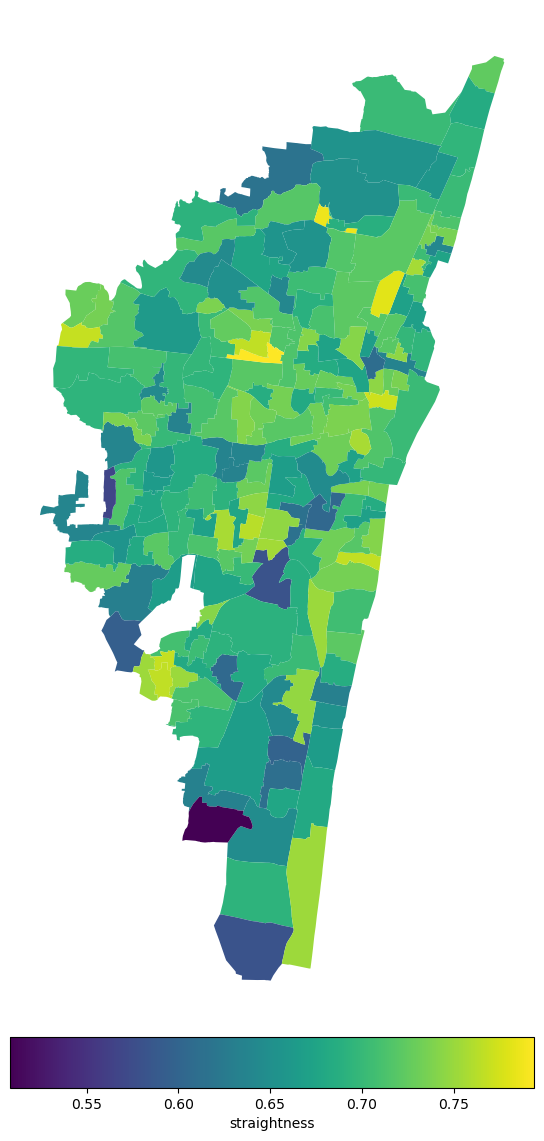

In [46]:
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 1, figsize=(14, 14))

divider = make_axes_locatable(ax)

cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_merged.plot(
    column="straightness",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={"label": "straightness", "orientation": "horizontal"},
)
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()